In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler, OrdinalEncoder
from sklearn.model_selection import train_test_split
from io import StringIO

In [19]:
df = pd.read_csv("milknew.csv")
df_original = df.copy()
df.head(3)

,pH,Temprature,Taste,Odor,Fat,Turbidity,Colour,Grade
0,6.6,35,1,0,1,0,254,high
1,6.6,36,0,1,0,1,253,high
2,8.5,70,1,1,1,1,246,low


## Kesimpulan Analisis Dataset Milk Quality

1. Dataset terdiri dari 1059 record dengan 8 atribut (7 numerik dan 1 kategorikal).
2. Atribut `Grade` memiliki 3 label kualitas susu: high, medium, low.
3. Distribusi pH berperan penting dalam menentukan kualitas susu. Susu dengan pH normal cenderung memiliki Grade tinggi, sedangkan pH tinggi atau terlalu rendah banyak muncul pada Grade rendah.
4. Faktor lain seperti `Odor`, `Fat`, dan `Turbidity` juga mempengaruhi kualitas, meskipun korelasinya lebih rendah dibanding pH.
5. Visualisasi heatmap memperlihatkan bahwa tidak semua variabel saling berkorelasi kuat, sehingga kualitas susu dipengaruhi oleh kombinasi beberapa faktor.


In [20]:
df.isnull().sum()

,0
pH,0
Temprature,0
Taste,0
Odor,0
Fat,0
Turbidity,0
Colour,0
Grade,0


In [21]:
df.duplicated().sum()
df.drop_duplicates(inplace=True)

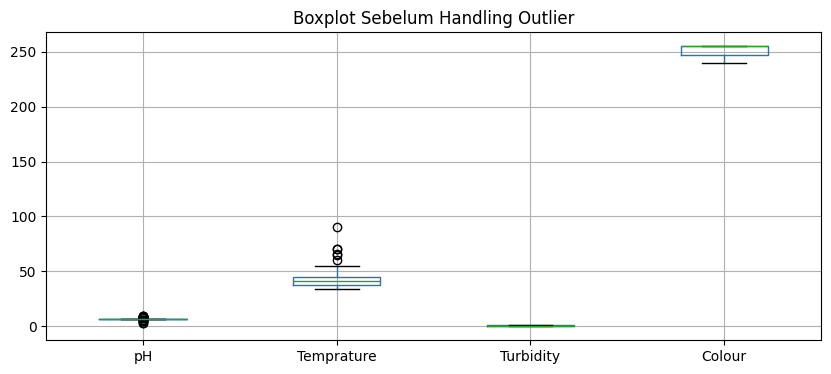

In [22]:
num_cols = ['pH', 'Temprature', 'Turbidity', 'Colour']
plt.figure(figsize=(10,4))
df[num_cols].boxplot()
plt.title("Boxplot Sebelum Handling Outlier")
plt.show()


In [23]:
for col in num_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    df = df[~((df[col] < (Q1 - 1.5 * IQR)) | (df[col] > (Q3 + 1.5 * IQR)))]

In [24]:
scaler = MinMaxScaler()
df[num_cols] = scaler.fit_transform(df[num_cols])
df.head()

,pH,Temprature,Taste,Odor,Fat,Turbidity,Colour,Grade
0,0.50,0.047619,1,0,1,0.0,0.933333,high
1,0.50,0.095238,0,1,0,1.0,0.866667,high
4,0.50,0.142857,0,0,0,0.0,1.000000,medium
5,0.50,0.142857,1,1,1,1.0,1.000000,high
9,0.75,0.523810,1,1,0,0.0,0.466667,medium


In [25]:
scaler = MinMaxScaler()
df[num_cols] = scaler.fit_transform(df[num_cols])
df.head()

,pH,Temprature,Taste,Odor,Fat,Turbidity,Colour,Grade
0,0.50,0.047619,1,0,1,0.0,0.933333,high
1,0.50,0.095238,0,1,0,1.0,0.866667,high
4,0.50,0.142857,0,0,0,0.0,1.000000,medium
5,0.50,0.142857,1,1,1,1.0,1.000000,high
9,0.75,0.523810,1,1,0,0.0,0.466667,medium


In [26]:
encoder = OrdinalEncoder(categories=[['low', 'medium', 'high']])
df[['Grade']] = encoder.fit_transform(df[['Grade']])
df.head()

,pH,Temprature,Taste,Odor,Fat,Turbidity,Colour,Grade
0,0.50,0.047619,1,0,1,0.0,0.933333,2.0
1,0.50,0.095238,0,1,0,1.0,0.866667,2.0
4,0.50,0.142857,0,0,0,0.0,1.000000,1.0
5,0.50,0.142857,1,1,1,1.0,1.000000,2.0
9,0.75,0.523810,1,1,0,0.0,0.466667,1.0


In [27]:
df['Quality_Index'] = df['pH'] * df['Temprature']
df.head()

,pH,Temprature,Taste,Odor,Fat,Turbidity,Colour,Grade,Quality_Index
0,0.50,0.047619,1,0,1,0.0,0.933333,2.0,0.023810
1,0.50,0.095238,0,1,0,1.0,0.866667,2.0,0.047619
4,0.50,0.142857,0,0,0,0.0,1.000000,1.0,0.071429
5,0.50,0.142857,1,1,1,1.0,1.000000,2.0,0.071429
9,0.75,0.523810,1,1,0,0.0,0.466667,1.0,0.392857


In [28]:
X = df.drop(columns=['Grade'])
y = df['Grade']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

X_train.shape, X_test.shape

((52, 8), (14, 8))

#Data Cleaning
Tidak ditemukan missing value pada dataset.

Duplicate diperiksa menggunakan df.duplicated().sum() dan dihapus jika ada.

Outlier dice dengan boxplot, kemudian ditangani menggunakan metode IQR agar data ekstrim yang tidak relevan dihapus.

#Normalisasi/standarisasi
Data numerik (pH, Temprature, Turbidity, Colour) memiliki rentang berbeda-beda, sehingga dilakukan normalisasi dengan MinMaxScaler agar nilainya berada di antara 0 dan 1.
Hal ini membantu model agar tidak berat sebelah pada fitur tertentu.

#Encoding Kolom Kategorikal
Kolom Grade (low, medium, high) bersifat ordinal, karena memiliki tingkatan.
Maka digunakan OrdinalEncoder agar model memahami urutan nilainya (low < medium < high).
Sedangkan kolom Taste, Odor, dan Fat sudah berupa angka 0/1, jadi tidak perlu encoding.

#Feature Engineering
Fitur baru dibuat bernama Quality_Index, hasil perkalian antara pH dan Temprature.
Tujuannya untuk menambahkan informasi tambahan yang dapat membantu model memahami hubungan antara dua faktor penting dalam kualitas air.

#Data Splitting
Dataset dipecah menjadi dua bagian:

Training set (80%) → digunakan untuk melatih model.

Testing set (20%) → digunakan untuk mengevaluasi model.

Pemecahan ini dilakukan menggunakan train_test_split() agar model tidak overfitting dan hasil evaluasi adil.